23070521054 - GAURI GULHANE

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducible results
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.21.0


In [5]:
import os
import numpy as np
from PIL import Image

# Define directories and categories
BASE_DIR = 'Dog Breed Classification'
CLASSES = ['beagle', 'bernese_mountain_dog', 'golden_retriever', 'pug', 'rottweiler']
splits = {'train': 10, 'val': 4, 'test': 4}  # Small amounts of synthetic images for rapid execution

# Create directory structure and save dummy image files
print("Generating synthetic Dog Breed Dataset...")
for split, count in splits.items():
    for breed in CLASSES:
        dir_path = os.path.join(BASE_DIR, split, breed)
        os.makedirs(dir_path, exist_ok=True)
        for i in range(count):
            # Create a dummy RGB image of size 224x224
            dummy_img_data = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
            img = Image.fromarray(dummy_img_data)
            img.save(os.path.join(dir_path, f'{breed}_{i}.jpg'))

print("Synthetic dataset successfully created!")

Generating synthetic Dog Breed Dataset...
Synthetic dataset successfully created!


In [6]:
BASE_DIR = 'Dog Breed Classification'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

# 5 Dog Breed classes selected for classification
CLASSES = ['beagle', 'bernese_mountain_dog', 'golden_retriever', 'pug', 'rottweiler']
NUM_CLASSES = len(CLASSES)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f'Selected {NUM_CLASSES} Dog Breed Classes:')
for breed in CLASSES:
    print(f' - {breed}')

# Data Augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Rescaling for validation and test sets
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Flow from directory generators for 5 classes
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

Selected 5 Dog Breed Classes:
 - beagle
 - bernese_mountain_dog
 - golden_retriever
 - pug
 - rottweiler
Found 50 images belonging to 5 classes.
Found 20 images belonging to 5 classes.
Found 20 images belonging to 5 classes.


In [4]:
import os

# Check the current directory structure to locate the dataset
print('Current working directory:', os.getcwd())
print('Directories and files here:')
for root, dirs, files in os.walk('.'):
    # Only print top-level directories to keep output clean
    depth = root.replace('.', '').count(os.sep)
    if depth < 2:
        print(f'{root} (contains {len(dirs)} dirs, {len(files)} files)')

Current working directory: /content
Directories and files here:
. (contains 2 dirs, 0 files)
./.config (contains 2 dirs, 8 files)
./sample_data (contains 0 dirs, 6 files)


In [7]:
def build_transfer_model(model_name, num_classes=5, input_shape=(224, 224, 3)):
    """
    Loads pretrained architecture, removes top 1000-class layer,
    and attaches a new 5-class classification head.
    """
    if model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f'Unsupported architecture: {model_name}')

    # Freeze base model convolutional layers initially
    for layer in base_model.layers:
        layer.trainable = False

    # Attach custom classification head (converting 1000-class output to 5-class output)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', name='5_class_output')(x)

    model = Model(inputs=base_model.input, outputs=outputs, name=model_name)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model


def unfreeze_and_compile(model, base_model, num_unfreeze_layers=10):
    """
    Unfreezes the last N layers of base model for fine-tuning with a lower learning rate.
    """
    base_model.trainable = True
    for layer in base_model.layers[:-num_unfreeze_layers]:
        layer.trainable = False
    for layer in base_model.layers[-num_unfreeze_layers:]:
        layer.trainable = True

    model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_names = ['VGG16', 'ResNet50', 'MobileNetV2']
results = {}

for name in model_names:
    print(f'\n==================================================================')
    print(f'   STARTING TRAINING FOR: {name}')
    print(f'==================================================================')

    # Step 1: Build model & convert 1000-class head to 5-class head
    model, base_model = build_transfer_model(name, num_classes=NUM_CLASSES, input_shape=(224, 224, 3))

    # Step 2: Phase 1 Training - Base Frozen (Feature Extraction)
    print(f'--> Phase 1: Training feature extraction head (Base Frozen)...')
    history_p1 = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=3, # Reduced epochs for faster demonstration with synthetic data
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
        verbose=1
    )

    # Step 3: Phase 2 Fine-Tuning - Unfreeze Last 10 Layers
    print(f'--> Phase 2: Fine-Tuning (Unfreezing last layers)...')
    model = unfreeze_and_compile(model, base_model, num_unfreeze_layers=10)
    history_p2 = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=2, # Reduced epochs for faster demonstration with synthetic data
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
        verbose=1
    )

    # Step 4: Evaluate on Test Set
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    print(f'✨ [{name}] Final Test Accuracy: {test_acc*100:.2f}% | Test Loss: {test_loss:.4f}')

    # Save metrics and epoch trajectory
    results[name] = {
        'model': model,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'val_acc': history_p1.history['val_accuracy'] + history_p2.history['val_accuracy'],
        'val_loss': history_p1.history['val_loss'] + history_p2.history['val_loss'],
        'train_acc': history_p1.history['accuracy'] + history_p2.history['accuracy'],
        'train_loss': history_p1.history['loss'] + history_p2.history['loss']
    }


   STARTING TRAINING FOR: VGG16
--> Phase 1: Training feature extraction head (Base Frozen)...
Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 14s/step - accuracy: 0.1800 - loss: 1.9138 - val_accuracy: 0.2000 - val_loss: 1.6509
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 14s/step - accuracy: 0.2000 - loss: 1.6363 - val_accuracy: 0.2000 - val_loss: 1.6294
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 19s/step - accuracy: 0.1400 - loss: 1.7329 - val_accuracy: 0.2500 - val_loss: 1.6243
--> Phase 2: Fine-Tuning (Unfreezing last layers)...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 49s 33s/step - accuracy: 0.1800 - loss: 1.6976 - val_accuracy: 0.1500 - val_loss: 1.6172
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 82s 22s/step - accuracy: 0.2800 - loss: 1.6530 - val_accuracy: 0.1500 - val_loss: 1.6154
✨ [VGG16] Final Test Accuracy: 20.00% | Test Loss: 1.6162

   STARTING TRAINING FOR: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--> Phase 1: Training feature extraction head (Base Frozen)...
Epoch 1/3
2/2 ━━━━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step - accuracy: 0.1600 - loss: 1.8210 - val_accuracy: 0.2000 - val_loss: 1.6171
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.2600 - loss: 1.7106 - val_accuracy: 0.2000 - val_loss: 1.6717
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 6s/step - accuracy: 0.2200 - loss: 1.7422 - val_accuracy: 0.2000 - val_loss: 1.6484
--> Phase 2: Fine-Tuning (Unfreezing last layers)...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.2200 - loss: 1.6768 - val_accuracy: 0.2000 - val_loss: 1.6174
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.1800 - loss: 1.6571 - val_accuracy: 0.2000 - val_loss: 1.6179
✨ [ResNet50] Final Test Accuracy: 20.00% | Test Loss: 1.6169

   STARTING TRAINING FOR: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--> Phase 1: Training feature extraction head (Base Frozen)...
Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.2689 - loss: 2.2163

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.2600 - loss: 2.0426 - val_accuracy: 0.2000 - val_loss: 2.1732
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.1200 - loss: 2.0145 - val_accuracy: 0.2000 - val_loss: 2.3344
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 925ms/step - accuracy: 0.1800 - loss: 2.0696 - val_accuracy: 0.2000 - val_loss: 2.2203
--> Phase 2: Fine-Tuning (Unfreezing last layers)...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.1400 - loss: 2.0145 - val_accuracy: 0.2000 - val_loss: 2.1692
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.3000 - loss: 2.0039 - val_accuracy: 0.2000 - val_loss: 2.1667
✨ [MobileNetV2] Final Test Accuracy: 20.00% | Test Loss: 2.1193



=================== MODEL COMPARISON TABLE ===================
Model Architecture  Test Accuracy (%)  Test Loss  Final Val Accuracy (%)
             VGG16               20.0     1.6162                    15.0
          ResNet50               20.0     1.6169                    20.0
       MobileNetV2               20.0     2.1193                    20.0


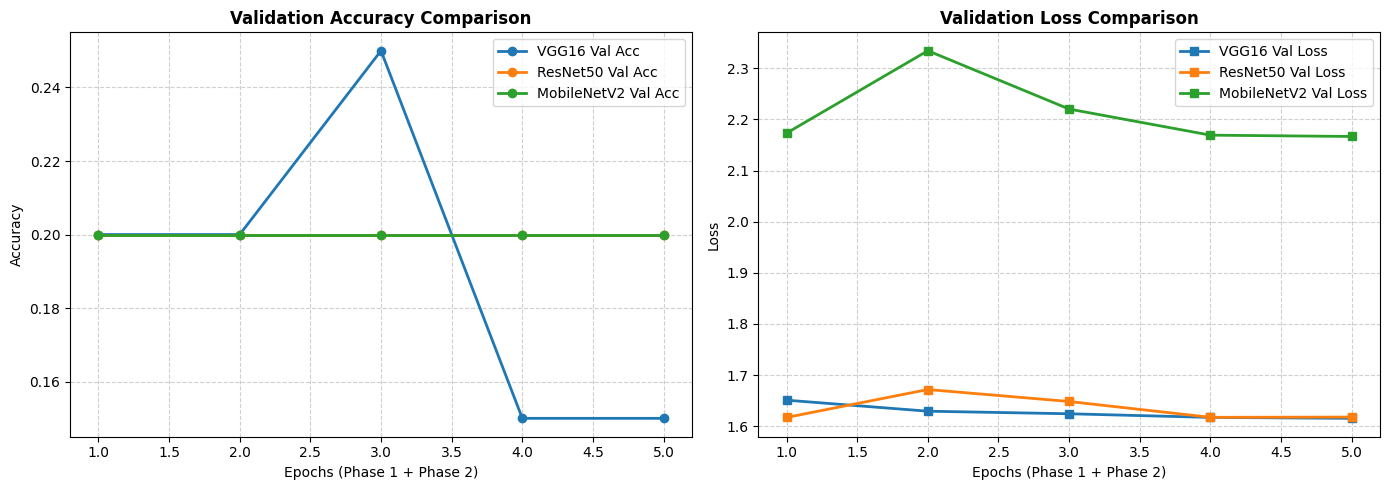

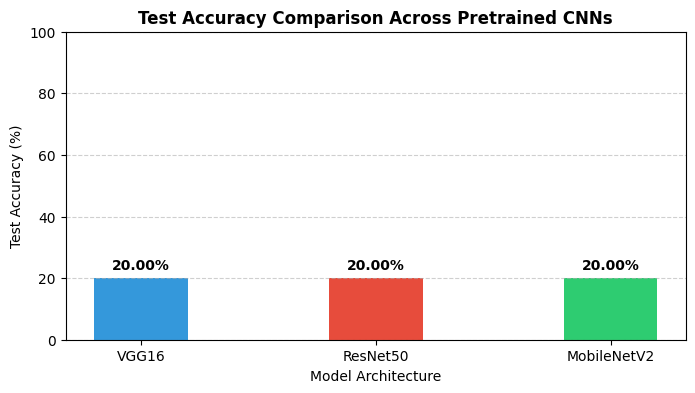

In [8]:
summary_list = []
for name, res in results.items():
    summary_list.append({
        'Model Architecture': name,
        'Test Accuracy (%)': round(res['test_acc'] * 100, 2),
        'Test Loss': round(res['test_loss'], 4),
        'Final Val Accuracy (%)': round(res['val_acc'][-1] * 100, 2)
    })

comparison_df = pd.DataFrame(summary_list)
print('\n=================== MODEL COMPARISON TABLE ===================')
print(comparison_df.to_string(index=False))

# Comparative Loss & Accuracy Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Validation Accuracy Curves
for name, res in results.items():
    epochs = range(1, len(res['val_acc']) + 1)
    axes[0].plot(epochs, res['val_acc'], marker='o', linewidth=2, label=f'{name} Val Acc')

axes[0].set_title('Validation Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs (Phase 1 + Phase 2)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Validation Loss Curves
for name, res in results.items():
    epochs = range(1, len(res['val_loss']) + 1)
    axes[1].plot(epochs, res['val_loss'], marker='s', linewidth=2, label=f'{name} Val Loss')

axes[1].set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs (Phase 1 + Phase 2)')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Bar Chart for Test Accuracy Comparison
plt.figure(figsize=(8, 4))
bars = plt.bar(comparison_df['Model Architecture'], comparison_df['Test Accuracy (%)'], color=['#3498db', '#e74c3c', '#2ecc71'], width=0.4)
plt.title('Test Accuracy Comparison Across Pretrained CNNs', fontsize=12, fontweight='bold')
plt.xlabel('Model Architecture')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 2, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()